In [246]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_recall_fscore_support, precision_score, fbeta_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

### LOAD DATASET

In [182]:
png = sns.load_dataset('penguins')
png.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### EDA + DROP MISSING VALUES

In [183]:
png.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [184]:
png[png.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [185]:
png.dropna(subset=[x for x in png.select_dtypes(include='number').columns], inplace=True)

In [186]:
png.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


### FEATURE ENGINEERING

In [187]:
# Converting scale 
png['bill_length_cm'] = png['bill_length_mm'] / 10
png['bill_depth_cm'] = png['bill_depth_mm'] / 10
png['flipper_length_cm'] = png['flipper_length_mm'] / 10
png['body_mass_kg'] = png['body_mass_g'] / 1000
png.drop(columns=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], inplace=True)

In [188]:
png.head()

,species,island,sex,bill_length_cm,bill_depth_cm,flipper_length_cm,body_mass_kg
0,Adelie,Torgersen,Male,3.91,1.87,18.1,3.75
1,Adelie,Torgersen,Female,3.95,1.74,18.6,3.80
2,Adelie,Torgersen,Female,4.03,1.80,19.5,3.25
4,Adelie,Torgersen,Female,3.67,1.93,19.3,3.45
5,Adelie,Torgersen,Male,3.93,2.06,19.0,3.65


### SPLIT DATASET PER FEATURES AND TARGET VALUES

In [189]:
features = png.drop(['species'], axis=1)
target = png['species']
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.3, random_state=39)

### CREATE PIPELINES 

In [190]:
numeric_features = [x for x in features.select_dtypes(include='number')]
cat_features = [x for x in features.select_dtypes(include='object')]
num_pipeline = Pipeline([('imputer', KNNImputer(n_neighbors=3)), ('scaler', StandardScaler())])
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(sparse_output=False, drop='first'))])
preprocessor = ColumnTransformer(transformers=[('numeric', num_pipeline, numeric_features), ('category', cat_pipeline, cat_features)])
# df = pd.DataFrame(preprocessor.fit_transform(features_train), columns=[x.split('__')[-1] for x in preprocessor.get_feature_names_out()])
# df

### INITIALIZE MODELS

In [217]:
model_1 = RandomForestClassifier(max_depth=3, random_state=39)
model_2 = KNeighborsClassifier(n_neighbors=5)
kf = KFold(n_splits=4, shuffle=True, random_state=42)

# MODEL 1: USE CROSS-VALIDATION
full_pipe = Pipeline([('preproc', preprocessor), ('classifier', model_1)])
score = cross_val_score(full_pipe, features, target, scoring='accuracy', cv=kf)
print(f'Scores of all iterations: {score}')
print(f'Mean value of all scores: {np.mean(score)}')

Scores of all iterations: [0.96511628 0.98837209 0.97647059 0.97647059]
Mean value of all scores: 0.9766073871409029


In [218]:
# MODEL 2: USE USUAL TRAINGIN SET 
full_pipe_2 = Pipeline([('preproc', preprocessor), ('classifier', model_2)])
full_pipe_2.fit(features_train, target_train)
pred = full_pipe_2.predict(features_test)
accuracy_2 = accuracy_score(target_test, pred)
accuracy_2

0.9902912621359223

In [213]:
# CREATE RANDOM SAMPLES
random_data = png.sample(150, random_state=150)
random_data

,species,island,sex,bill_length_cm,bill_depth_cm,flipper_length_cm,body_mass_kg
54,Adelie,Biscoe,Female,3.45,1.81,18.7,2.90
84,Adelie,Dream,Female,3.73,1.78,19.1,3.35
165,Chinstrap,Dream,Male,5.20,1.81,20.1,4.05
43,Adelie,Dream,Male,4.41,1.97,19.6,4.40
220,Gentoo,Biscoe,Female,4.61,1.32,21.1,4.50
...,...,...,...,...,...,...,...
311,Gentoo,Biscoe,Male,5.22,1.71,22.8,5.40
65,Adelie,Biscoe,Male,4.16,1.80,19.2,3.95
216,Chinstrap,Dream,Female,4.35,1.81,20.2,3.40
94,Adelie,Dream,Female,3.62,1.73,18.7,3.30


In [195]:
extra_features = random_data.drop(['species'], axis=1)
extra_target = random_data['species']

In [214]:
# CHECK ACCURACY ON THE RANDOM TEST SAMPLES(MODEL 1 AND MODEL 2)
extra_pred_model_1 = full_pipe.predict(extra_features)
extra_pred_model_2 = full_pipe_2.predict(extra_features)
acc1 = accuracy_score(extra_target, extra_pred_model_1)
acc2 = accuracy_score(extra_target, extra_pred_model_2)
print(f'Accuracy of model 1: {acc1}')
print(f'Accuracy of model 2: {acc2}')

Accuracy of model 1: 0.98
Accuracy of model 2: 0.9866666666666667


### GridSearchCV

In [275]:
grid_param = {
    'preproc__numeric__imputer__n_neighbors': [2, 3, 4, 5, 6],
    'classifier__n_estimators': [2, 3, 5, 10, 20, 50, 100, 200],
    'classifier__max_depth': [2, 3, 5, 10, None]
}
grid_s = GridSearchCV(full_pipe, grid_param, cv=kf, verbose=1, scoring='accuracy')
grid_s.fit(features, target)


Fitting 4 folds for each of 200 candidates, totalling 800 fits


,estimator,Pipeline(step...m_state=39))])
,param_grid,"{'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [2, 3, ...], 'preproc__numeric__imputer__n_neighbors': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('category', ...)]"


In [219]:
grid_params_2 = {
    'preproc__numeric__imputer__n_neighbors': [2, 3, 4, 5, 6],
    'classifier__n_neighbors': [1, 2, 3, 4, 5, 7, 10],
    'classifier__p': [1, 2, 3, 5]
}
grid_s_1 = GridSearchCV(full_pipe_2, grid_params_2, scoring='accuracy', cv=kf, verbose=1)
grid_s_1.fit(features, target)

Fitting 4 folds for each of 140 candidates, totalling 560 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'classifier__n_neighbors': [1, 2, ...], 'classifier__p': [1, 2, ...], 'preproc__numeric__imputer__n_neighbors': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('category', ...)]"


In [222]:
print(f'Best parameters(model 1): {grid_s.best_params_}')
print(f'Best score (model 1): {grid_s.best_score_}')
print(f'Best parameters(model 2): {grid_s_1.best_params_}')
print(f'Best score (model 2): {grid_s_1.best_score_}')

Best parameters(model 1): {'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'preproc__numeric__imputer__n_neighbors': 2}
Best score (model 1): 0.9912448700410397
Best parameters(model 2): {'classifier__n_neighbors': 1, 'classifier__p': 5, 'preproc__numeric__imputer__n_neighbors': 2}
Best score (model 2): 1.0


In [223]:
best_model = grid_s.best_estimator_  # BEST MODEL WITHOUT OVERFITTING!!!

### Evaluate accuray, recall, f1-score

In [200]:
random_set = png.sample(180)
F, T = random_set.drop(['species'], axis=1), random_set['species']

In [245]:
any_pred = best_model.predict(F)

In [224]:
# ACCURACY
any_accuracy = accuracy_score(T, any_pred)
any_accuracy

0.9944444444444445

In [239]:
# RECALL 
recall = recall_score(T, any_pred, average=None)
recall

array([1.        , 0.97058824, 1.        ])

In [240]:
# PRECISION
prec = precision_score(T, any_pred, average=None)
prec

array([0.98780488, 1.        , 1.        ])

In [243]:
# F1-SCORE
f1 = f1_score(T, any_pred, average=None)
f1

array([0.99386503, 0.98507463, 1.        ])

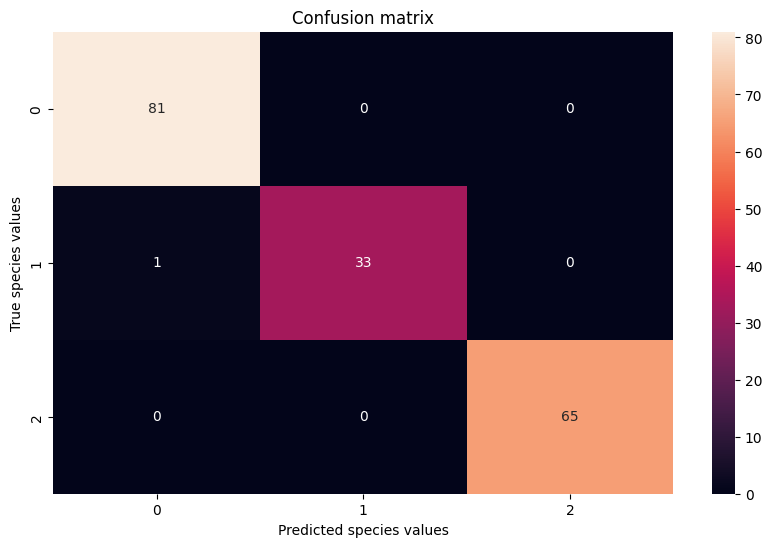

In [249]:
# CONFUSION MATRIX
conf_mat = confusion_matrix(T, any_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(conf_mat, annot=True)
plt.title('Confusion matrix')
plt.ylabel('True species values')
plt.xlabel('Predicted species values')
plt.show()

In [274]:
# INITIALIZE NEW UNKNOWN DATASET
peng_2 = {'species': ['Adelie', 'Adelie', 'Gentoo', 'Chinstrap'],
          'island': ['Torgersen', 'Biscoe', 'Dream', 'Torgersen'],
          'sex': ['Male', 'Male', 'Female', 'Male'],
          'bill_length_cm': [3.45, 3.89, 4.81, 5.20],
          'bill_depth_cm': [1.80, 2.00, 1.52, 1.52],
          'flipper_length_cm': [17.7, 17.8, 21.2, 17.5],
          'body_mass_kg': [3.2, 3.6, 4.2, 3.9]
        }

In [266]:
peng_2 = pd.DataFrame(peng_2)
peng_2

,species,island,sex,bill_length_cm,bill_depth_cm,flipper_length_cm,body_mass_kg
0,Adelie,Torgersen,Male,3.45,1.80,17.7,3.2
1,Adelie,Biscoe,Male,3.89,2.00,17.8,3.6
2,Gentoo,Dream,Female,4.81,1.52,21.2,4.2
3,Chinstrap,Torgersen,Male,5.20,1.52,17.5,3.9


In [271]:
best_model_knn = grid_s_1.best_estimator_
Ftr, Tat = peng_2.drop(['species'], axis=1), peng_2['species']

In [272]:
add_pred = best_model.predict(Ftr)
add_pred_1 = best_model_knn.predict(Ftr)

In [270]:
accur = accuracy_score(Tat, add_pred)
accur

0.75

In [273]:
accur_1 = accuracy_score(Tat, add_pred_1)
accur_1

1.0

In [2]:
import numpy as np
arr = np.arange(1, 13).reshape(6, 2)
arr

array([[ 1,  2],
       [ 3,  4],
       [ 5,  6],
       [ 7,  8],
       [ 9, 10],
       [11, 12]])

In [4]:
res = np.sum(arr, axis=1)
res

array([ 3,  7, 11, 15, 19, 23])